# Escalation Magnitude: Bet Ratio After Wins vs. Losses

This notebook adds
a **ratio** column, `BetRatio = Bet / PrevBet`, which captures *how much* the bet
changed:

- `BetRatio = 1.0` -> bet stayed the same size
- `BetRatio = 2.0` -> the player doubled their bet
- `BetRatio = 0.5` -> the player cut their bet in half

We compare the distribution of `BetRatio` after a win vs. after a loss with a
boxplot, then use a **Mann-Whitney U test** to check whether the difference
between those two distributions is statistically real rather than something
that could plausibly happen by chance. Mann-Whitney is used instead of a
t-test because bet ratios are heavily skewed (a few players multiply their bet
many times over), so the test shouldn't assume a normal distribution.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

from poker_coach.config import GRAPE_SODA, MUTED_TEAL, BUSTABIT_DATA_FILE

sns.set_theme(style='darkgrid')

df = pd.read_csv(BUSTABIT_DATA_FILE, na_values=['NA'], parse_dates=['PlayDate'])
df['Won'] = df['CashedOut'].notna()   # missing CashedOut = player busted (lost)

df = df.sort_values(['Username', 'PlayDate']).reset_index(drop=True)  # each player's bets in time order
df['PrevBet'] = df.groupby('Username')['Bet'].shift(1)   # size of that player's previous bet
df['PrevWon'] = df.groupby('Username')['Won'].shift(1)   # outcome of that player's previous bet

seq_df = df.dropna(subset=['PrevBet', 'PrevWon']).copy()  # drop first-ever bets (no history)
seq_df['PrevOutcome'] = seq_df['PrevWon'].map({True: 'After Win', False: 'After Loss'})

print(f"There are {len(seq_df):,} sequential bets to compare after wins vs after losses")


There are 45,851 sequential bets to compare after wins vs after losses


## Create the `BetRatio` Column

`BetRatio` is simply the current bet divided by the previous bet. No bet in
this dataset is ever 0, so this division is always safe.


In [2]:
seq_df['BetRatio'] = seq_df['Bet'] / seq_df['PrevBet']

seq_df[['Username', 'PlayDate', 'PrevBet', 'Bet', 'BetRatio', 'PrevOutcome']].head(8)


,Username,PlayDate,PrevBet,Bet,BetRatio,PrevOutcome
1,----------------,2016-11-03 15:05:40+00:00,11.0,12,1.090909,After Win
2,----------------,2016-11-03 20:26:24+00:00,12.0,8,0.666667,After Win
4,--dilib--,2016-11-02 00:56:16+00:00,349.0,98,0.280802,After Win
5,--dilib--,2016-11-02 07:30:53+00:00,98.0,311,3.173469,After Win
6,--dilib--,2016-11-02 11:03:15+00:00,311.0,167,0.536977,After Loss
7,--dilib--,2016-11-02 17:31:02+00:00,167.0,757,4.532934,After Loss
8,--dilib--,2016-11-03 08:39:20+00:00,757.0,2,0.002642,After Loss
9,--dilib--,2016-11-03 08:48:12+00:00,2.0,1,0.500000,After Loss


## Boxplot: Bet Ratio After a Win vs. After a Loss

`BetRatio` is a multiplicative quantity (doubling and halving are equally
"sized" changes in opposite directions), so we plot it on a **log scale** -
that puts `BetRatio = 1` (no change) in the middle, with escalation (`> 1`)
and de-escalation (`< 1`) spread out evenly on either side.


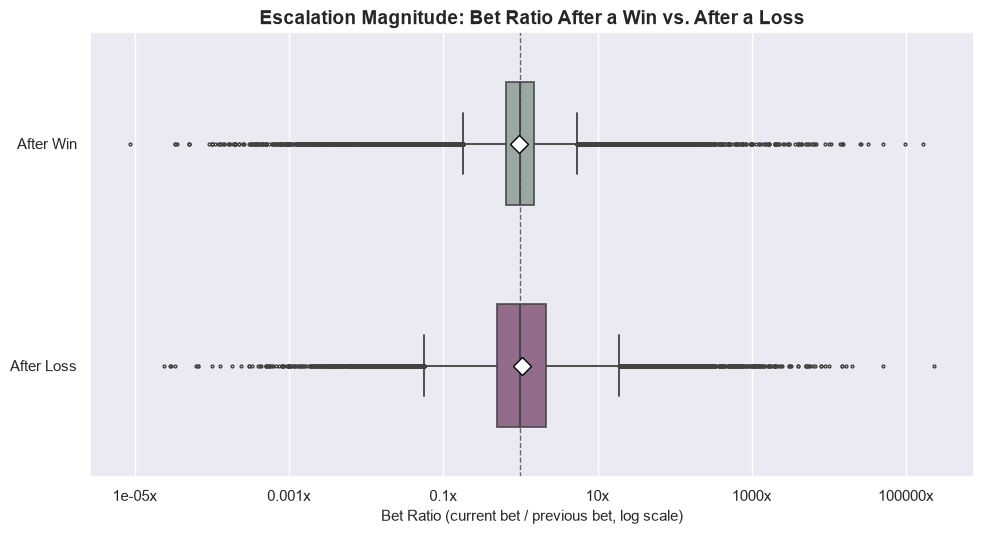

,median,mean,Q1,Q3
PrevOutcome,,,,
After Loss,1.0,34.906,0.500,2.152
After Win,1.0,30.067,0.642,1.500


In [6]:
order = ['After Win', 'After Loss']
palette = {'After Win': MUTED_TEAL, 'After Loss': GRAPE_SODA}

summary = seq_df.groupby('PrevOutcome')['BetRatio'].agg(
    median='median', mean='mean', Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.boxplot(
    data=seq_df, x='BetRatio', y='PrevOutcome', order=order, hue='PrevOutcome', palette=palette,
    legend=False, log_scale=True, width=0.55, fliersize=2, linewidth=1.3, boxprops={'alpha': 0.85},
    showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 9},
    ax=ax,
)

ax.axvline(1.0, color='0.4', linestyle='--', linewidth=1)  # reference line: "bet unchanged"
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}x'))

ax.set_title('Escalation Magnitude: Bet Ratio After a Win vs. After a Loss', fontsize=14, fontweight='bold')
ax.set_xlabel('Bet Ratio (current bet / previous bet, log scale)', fontsize=11)
ax.set_ylabel('')

plt.tight_layout()
plt.show()

summary.round(3)


## Mann-Whitney U Test

The Mann-Whitney U test checks whether one group's values tend to be larger
than the other's, without assuming the data is normally distributed - a good
fit here since `BetRatio` is skewed (most changes are small, a few are huge).
It works by ranking all the ratios together and comparing how those ranks are
split between the "After Win" and "After Loss" groups.

- **Null hypothesis:** the `BetRatio` after a win and after a loss come from
  the same distribution (no real difference).
- **Alternative hypothesis:** they come from different distributions.
- We treat `p < 0.05` as evidence the difference is unlikely to be due to
  chance alone.


In [4]:
after_win_ratios = seq_df.loc[seq_df['PrevOutcome'] == 'After Win', 'BetRatio']
after_loss_ratios = seq_df.loc[seq_df['PrevOutcome'] == 'After Loss', 'BetRatio']

u_stat, p_value = stats.mannwhitneyu(after_loss_ratios, after_win_ratios, alternative='two-sided')

print(f"Mann-Whitney U statistic: {u_stat:,.0f}")
print(f"p-value: {p_value:.4g}")

if p_value < 0.05:
    print("\nResult: statistically significant difference (p < 0.05) between "
          "bet-ratio distributions after a win vs. after a loss.")
else:
    print("\nResult: no statistically significant difference detected (p >= 0.05).")

median_diff = summary.loc['After Loss', 'median'] - summary.loc['After Win', 'median']
print(f"\nMedian BetRatio after a loss: {summary.loc['After Loss', 'median']:.3f}")
print(f"Median BetRatio after a win:  {summary.loc['After Win', 'median']:.3f}")
print(f"Difference in medians:        {median_diff:+.3f}")


Mann-Whitney U statistic: 258,799,017
p-value: 0.1668

Result: no statistically significant difference detected (p >= 0.05).

Median BetRatio after a loss: 1.000
Median BetRatio after a win:  1.000
Difference in medians:        +0.000


## Interpretation

The BetRatio column: current bet ÷ previous bet. A value of 1.0 = bet stayed the same size, 2.0 = doubled, 0.5 = cut in half.

Central tendency: the median BetRatio is exactly 1.0 in both groups — after a win and after a loss. So the typical bet doesn't get bigger or smaller either way; most players' next bet is unchanged from their last one, regardless of outcome.

The boxplot: the "After Loss" box is visibly wider than the "After Win" box (middle 50% of ratios ≈ 0.50–2.15x after a loss, vs. ≈ 0.64–1.50x after a win). That means bet sizes swing further in both directions after a loss — bigger jumps up and bigger cuts down — not a shift toward larger bets specifically.

The Mann-Whitney U test: p = 0.167, which is above the standard 0.05 cutoff. This test checks whether one group's values tend to rank systematically higher than the other's. The result here means: we cannot conclude that bet-size changes after a loss are, overall, larger (in the "increased" direction) than after a win.

What this adds up to: on its own, this analysis does not find statistically significant evidence that players escalate their bet size more after a loss than after a win. The one concrete effect it does show is increased volatility after a loss — bet sizes move further from the previous bet in general — but that's a spread/dispersion effect, not a directional "loss chasing" effect, and it isn't strong enough to register as significant in this test.